## 1. Imports

In [1]:
import warnings, joblib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
warnings.filterwarnings("ignore")

from sklearn.model_selection    import train_test_split, StratifiedKFold
from sklearn.preprocessing      import StandardScaler
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm                import SVC
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.tree               import DecisionTreeClassifier
from sklearn.naive_bayes        import GaussianNB
from sklearn.metrics            import (accuracy_score, classification_report,
                                         roc_auc_score, roc_curve,
                                         confusion_matrix, ConfusionMatrixDisplay)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost ✅")
except: XGBOOST_AVAILABLE = False; print("XGBoost ❌")

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print("SMOTE  ✅")
except:
    SMOTE_AVAILABLE = False
    print("SMOTE  ❌ — pip install imbalanced-learn")

OUTPUT_DIR  = Path("outputs_tabular_fixed")
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_SEED = 42
N_FOLDS     = 5
np.random.seed(RANDOM_SEED)
print("Imports done.")

XGBoost ✅
SMOTE  ✅
Imports done.


## 2. Load Dataset

In [2]:

CSV_PATH = "Second Dataset (1).csv"


df = pd.read_csv(CSV_PATH)
df.rename(columns={"BS":"Blood Sugar"}, inplace=True)
print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nRisk Level:")
print(df["Risk Level"].value_counts())
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum()>0] if df.isnull().sum().sum()>0 else "None")

Shape  : (1205, 12)
Columns: ['Age', 'Systolic BP', 'Diastolic', 'Blood Sugar', 'Body Temp', 'BMI', 'Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Heart Rate', 'Risk Level']

Risk Level:
Risk Level
Low     713
High    474
Name: count, dtype: int64

Missing values:
Systolic BP                5
Diastolic                  4
Blood Sugar                2
BMI                       18
Previous Complications     2
Preexisting Diabetes       2
Heart Rate                 2
Risk Level                18
dtype: int64


## 3. EDA

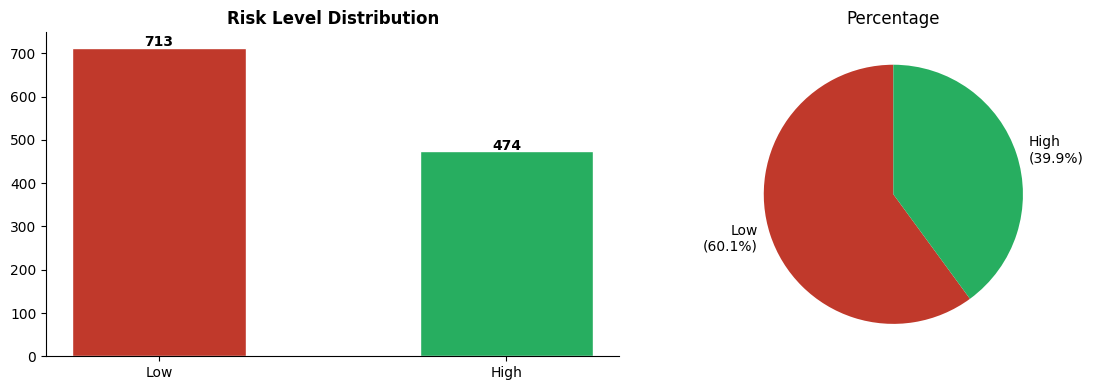

In [3]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
counts = df["Risk Level"].value_counts()
colors = ["#c0392b","#27ae60"]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Risk Level Distribution",fontweight="bold")
for i,(idx,v) in enumerate(counts.items()):
    axes[0].text(i,v+3,str(v),ha="center",fontweight="bold")
axes[0].spines[["top","right"]].set_visible(False)
pct = df["Risk Level"].value_counts(normalize=True)*100
axes[1].pie(pct.values,
            labels=[f"{l}\n({v:.1f}%)" for l,v in zip(pct.index,pct.values)],
            colors=colors, startangle=90)
axes[1].set_title("Percentage")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"01_class_distribution.png",dpi=150,bbox_inches="tight")
plt.show()

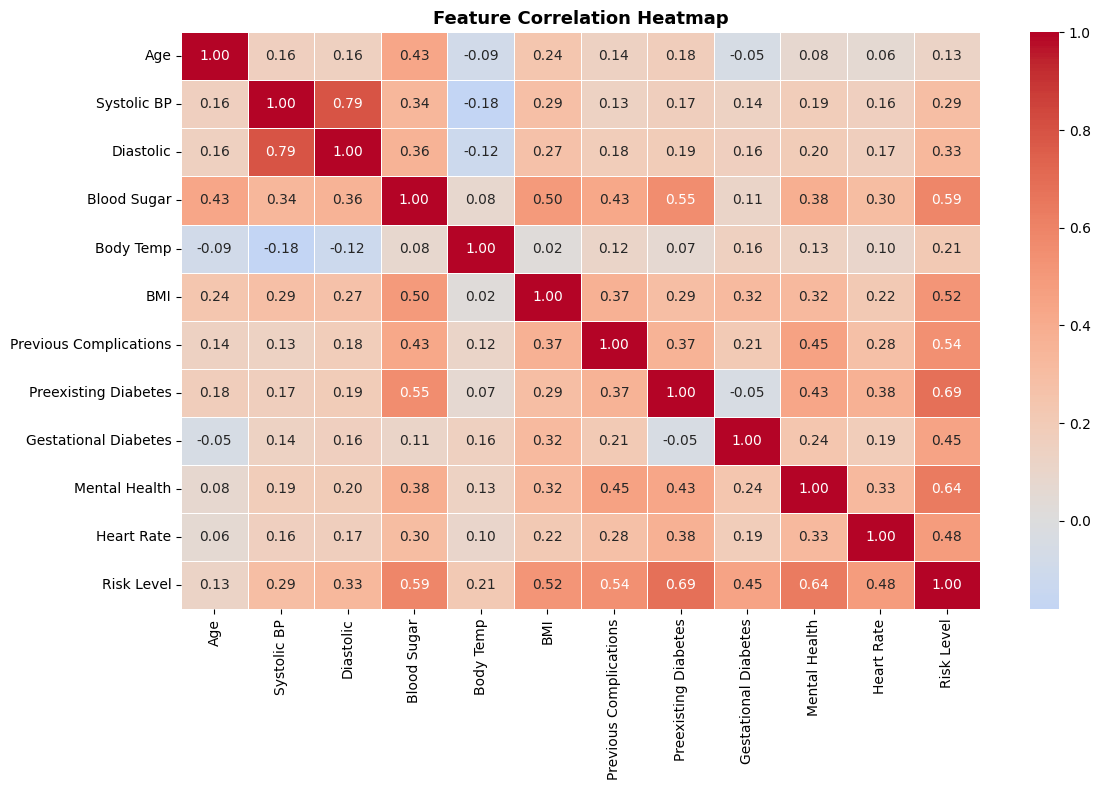

In [4]:
# Correlation heatmap
temp = df.copy()
temp["Risk Level"] = temp["Risk Level"].map({"Low":0,"High":1})
fig, ax = plt.subplots(figsize=(12,8))
sns.heatmap(temp.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("Feature Correlation Heatmap",fontweight="bold",fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"02_correlation_heatmap.png",dpi=150,bbox_inches="tight")
plt.show()

## 4. Preprocessing — Split First, Scale Second

In [5]:
df_clean = df.copy()
df_clean = df_clean.dropna(subset=["Risk Level"]).drop_duplicates()
df_clean = df_clean[df_clean["Age"] <= 100]
df_clean["BMI"] = df_clean["BMI"].replace(0, np.nan)
df_clean["risk_label"] = df_clean["Risk Level"].map({"Low":0,"High":1})
df_clean = df_clean.drop("Risk Level", axis=1)

X = df_clean.drop("risk_label", axis=1)
y = df_clean["risk_label"].astype(int)

# ── CRITICAL: Split FIRST ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

# Impute with TRAIN statistics only
num_cols = ["Systolic BP","Diastolic","Blood Sugar","BMI","Heart Rate"]
bin_cols  = ["Previous Complications","Preexisting Diabetes",
             "Gestational Diabetes","Mental Health"]
for c in num_cols:
    med = X_train[c].median()
    X_train[c].fillna(med, inplace=True)
    X_test[c].fillna(med,  inplace=True)
for c in bin_cols:
    if c in X_train.columns:
        mode = X_train[c].mode()[0]
        X_train[c].fillna(mode, inplace=True)
        X_test[c].fillna(mode,  inplace=True)

# Scale with TRAIN statistics only
scaler     = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print(f"Train: {len(X_train_sc)} | Test: {len(X_test_sc)}")
print(f"Class dist (train): {dict(y_train.value_counts())}")
print(f"Class dist (test) : {dict(y_test.value_counts())}")
print("✅ Scaler fit on train only — zero leakage")

Train: 934 | Test: 234
Class dist (train): {0: np.int64(556), 1: np.int64(378)}
Class dist (test) : {0: np.int64(139), 1: np.int64(95)}
✅ Scaler fit on train only — zero leakage


## 5. SMOTE Balancing (Synthetic Minority Oversampling)

In [6]:
if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=RANDOM_SEED)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)
    print(f"After SMOTE: {dict(pd.Series(y_train_bal).value_counts())}")
    print("✅ SMOTE generates SYNTHETIC samples — no memorization")
else:
    # Fallback: use class weights in model instead
    from sklearn.utils import resample as sk_resample
    df_tr = X_train_sc.copy(); df_tr["label"] = y_train.values
    low   = df_tr[df_tr.label==0]; high = df_tr[df_tr.label==1]
    maj   = max(len(low),len(high))
    low_r  = sk_resample(low,  replace=True, n_samples=maj, random_state=RANDOM_SEED)
    high_r = sk_resample(high, replace=True, n_samples=maj, random_state=RANDOM_SEED)
    bal    = pd.concat([low_r,high_r]).sample(frac=1,random_state=RANDOM_SEED)
    X_train_bal = bal.drop("label",axis=1).values
    y_train_bal = bal["label"].values
    print(f"After resampling: {dict(pd.Series(y_train_bal).value_counts())}")
    print("⚠️  Using duplication (install imbalanced-learn for SMOTE)")

print(f"Balanced train size: {len(X_train_bal)}")

After SMOTE: {0: np.int64(556), 1: np.int64(556)}
✅ SMOTE generates SYNTHETIC samples — no memorization
Balanced train size: 1112


## 6. Define Models

In [7]:
def get_models():
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000,
                                random_state=RANDOM_SEED, C=1.0),
        "Decision Tree":       DecisionTreeClassifier(max_depth=8,
                                random_state=RANDOM_SEED),
        "Random Forest":       RandomForestClassifier(n_estimators=200,
                                random_state=RANDOM_SEED, n_jobs=-1),
        "SVM (RBF)":           SVC(kernel="rbf", probability=True,
                                random_state=RANDOM_SEED, C=1.0),
        "KNN":                 KNeighborsClassifier(n_neighbors=5),
        "Naive Bayes":         GaussianNB(),
        "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100,
                                random_state=RANDOM_SEED),
    }
    if XGBOOST_AVAILABLE:
        models["XGBoost"] = XGBClassifier(n_estimators=100,
                            random_state=RANDOM_SEED,
                            eval_metric="logloss", verbosity=0)
    return models

print(f"Models defined: {list(get_models().keys())}")

Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM (RBF)', 'KNN', 'Naive Bayes', 'Gradient Boosting', 'XGBoost']


## 7. 5-Fold Cross Validation on All Models

In [8]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Store per-fold metrics for each model
all_fold_metrics = {name: [] for name in get_models().keys()}

print(f"Running {N_FOLDS}-Fold CV on {len(get_models())} models...\n")

for fold, (tr_idx, val_idx) in enumerate(
        skf.split(X_train_bal, y_train_bal), 1):

    X_fold_tr = X_train_bal[tr_idx] if isinstance(X_train_bal, np.ndarray)                 else X_train_bal.iloc[tr_idx]
    X_fold_val= X_train_bal[val_idx] if isinstance(X_train_bal, np.ndarray)                 else X_train_bal.iloc[val_idx]
    y_fold_tr = y_train_bal[tr_idx]  if isinstance(y_train_bal, np.ndarray)                 else y_train_bal.iloc[tr_idx]
    y_fold_val= y_train_bal[val_idx] if isinstance(y_train_bal, np.ndarray)                 else y_train_bal.iloc[val_idx]

    for name, clf in get_models().items():
        clf.fit(X_fold_tr, y_fold_tr)
        preds = clf.predict(X_fold_val)
        probs = clf.predict_proba(X_fold_val)[:,1]
        rep   = classification_report(y_fold_val, preds,
                target_names=["Low","High"], output_dict=True, zero_division=0)
        all_fold_metrics[name].append({
            "Accuracy":  accuracy_score(y_fold_val, preds),
            "Precision": rep["High"]["precision"],
            "Recall":    rep["High"]["recall"],
            "F1-Score":  rep["High"]["f1-score"],
            "ROC-AUC":   roc_auc_score(y_fold_val, probs),
        })

    print(f"Fold {fold}/{N_FOLDS} done ✅")

print("\nAll folds complete.")

Running 5-Fold CV on 8 models...

Fold 1/5 done ✅
Fold 2/5 done ✅
Fold 3/5 done ✅
Fold 4/5 done ✅
Fold 5/5 done ✅

All folds complete.


## 8. CV Results Summary — Mean ± Std (IEEE Format)

In [10]:
summary_rows = []
for name, fold_list in all_fold_metrics.items():
    fold_df = pd.DataFrame(fold_list)
    row = {"Model": name}
    for col in fold_df.columns:
        row[col]         = fold_df[col].mean()
        row[f"{col}_std"]= fold_df[col].std()
    summary_rows.append(row)

cv_summary = pd.DataFrame(summary_rows).sort_values("Accuracy",
             ascending=False).reset_index(drop=True)
cv_summary.index += 1

print("=" * 75)
print("   TABULAR BRANCH — 5-FOLD CV RESULTS")
print("=" * 75)
print(f"{'Model':<22} {'Accuracy':>14} {'AUC':>14} {'F1':>14}")
print("-" * 75)
for _, row in cv_summary.iterrows():
    print(f"{row['Model']:<22} "
          f"{row['Accuracy']:.4f}±{row['Accuracy_std']:.4f}  "
          f"{row['ROC-AUC']:.4f}±{row['ROC-AUC_std']:.4f}  "
          f"{row['F1-Score']:.4f}±{row['F1-Score_std']:.4f}")
print("=" * 75)
print(f"\n Best: {cv_summary.iloc[0]['Model']} "
      f"(Acc={cv_summary.iloc[0]['Accuracy']:.4f}±"
      f"{cv_summary.iloc[0]['Accuracy_std']:.4f})")

cv_summary.to_csv(OUTPUT_DIR/"cv_summary_all_models.csv", index=False)

   TABULAR BRANCH — 5-FOLD CV RESULTS
Model                        Accuracy            AUC             F1
---------------------------------------------------------------------------
Gradient Boosting      0.9901±0.0067  0.9996±0.0002  0.9901±0.0067
XGBoost                0.9892±0.0081  0.9990±0.0010  0.9892±0.0081
Random Forest          0.9883±0.0051  0.9995±0.0006  0.9883±0.0051
SVM (RBF)              0.9793±0.0051  0.9980±0.0008  0.9794±0.0051
Decision Tree          0.9694±0.0148  0.9703±0.0145  0.9693±0.0152
KNN                    0.9694±0.0103  0.9946±0.0043  0.9696±0.0102
Logistic Regression    0.9685±0.0084  0.9942±0.0032  0.9685±0.0084
Naive Bayes            0.9343±0.0173  0.9922±0.0050  0.9302±0.0192

 Best: Gradient Boosting (Acc=0.9901±0.0067)


## 9. Train Best Model on Full Train Set + Test Evaluation

In [11]:
best_model_name = cv_summary.iloc[0]["Model"]
models_dict     = get_models()
best_clf        = models_dict[best_model_name]

print(f"Training best model: {best_model_name}")
best_clf.fit(X_train_bal, y_train_bal)

# Test evaluation
test_preds = best_clf.predict(np.array(X_test_sc))
test_probs = best_clf.predict_proba(np.array(X_test_sc))[:,1]
test_acc   = accuracy_score(y_test, test_preds)
test_auc   = roc_auc_score(y_test, test_probs)

print(f"\nTest Set Results — {best_model_name}:")
print("=" * 55)
print(classification_report(y_test, test_preds,
      target_names=["Low Risk","High Risk"]))
print(f"ROC-AUC: {test_auc:.4f}")

# Save model and scaler
joblib.dump(best_clf, OUTPUT_DIR/"tabular_best_model.pkl")
joblib.dump(scaler,   OUTPUT_DIR/"tabular_scaler.pkl")
print("\nModel and scaler saved ")

Training best model: Gradient Boosting

Test Set Results — Gradient Boosting:
              precision    recall  f1-score   support

    Low Risk       0.99      0.99      0.99       139
   High Risk       0.99      0.98      0.98        95

    accuracy                           0.99       234
   macro avg       0.99      0.99      0.99       234
weighted avg       0.99      0.99      0.99       234

ROC-AUC: 0.9998

Model and scaler saved 


## 10. Feature Importance

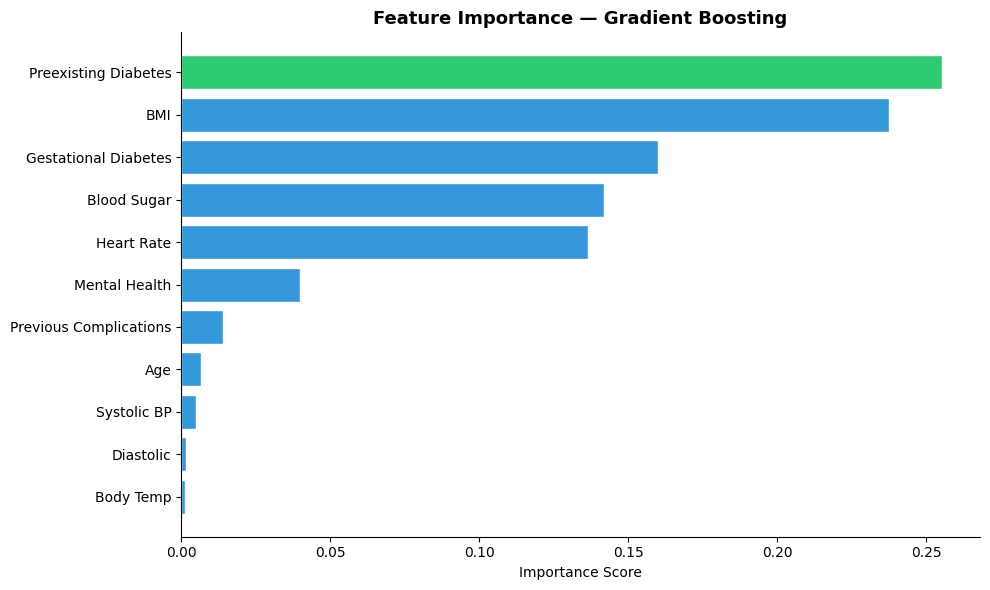

In [12]:
if hasattr(best_clf, "feature_importances_"):
    importances = best_clf.feature_importances_
elif hasattr(best_clf, "coef_"):
    importances = np.abs(best_clf.coef_[0])
else:
    importances = np.ones(len(X.columns))

imp_df = pd.DataFrame({"Feature":X.columns,"Importance":importances})
imp_df = imp_df.sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10,6))
colors_imp = ["#2ecc71" if v==imp_df["Importance"].max()
              else "#3498db" for v in imp_df["Importance"]]
ax.barh(imp_df["Feature"], imp_df["Importance"],
        color=colors_imp, edgecolor="white")
ax.set_title(f"Feature Importance — {best_model_name}",
             fontweight="bold",fontsize=13)
ax.set_xlabel("Importance Score")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"03_feature_importance.png",dpi=150,bbox_inches="tight")
plt.show()

## 11. Plots — Comparison + ROC + Confusion Matrix

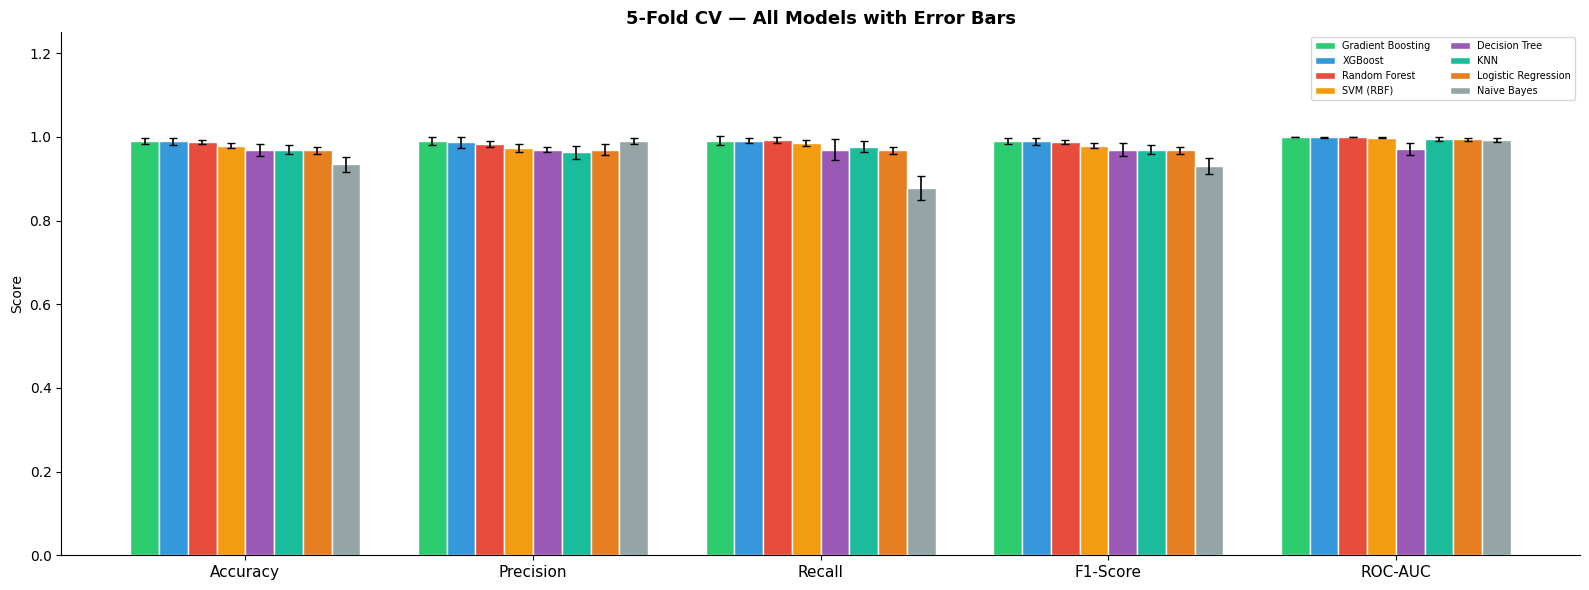

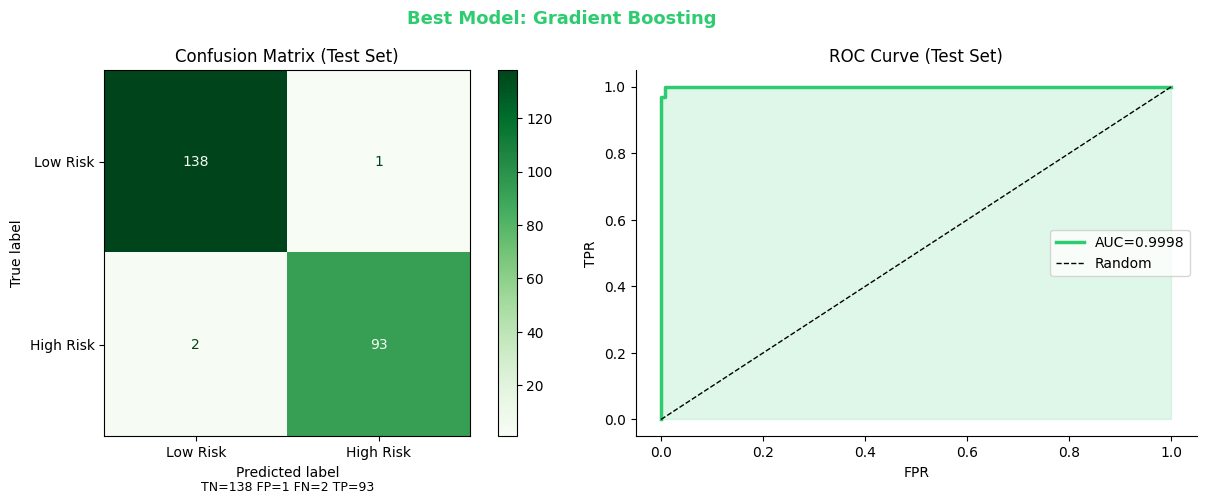

In [13]:
# CV comparison bar with error bars
metric_cols = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
fig, ax = plt.subplots(figsize=(16,6))
x, width = np.arange(len(metric_cols)), 0.10
colors_m  = ["#2ecc71","#3498db","#e74c3c","#f39c12",
              "#9b59b6","#1abc9c","#e67e22","#95a5a6"]

for i,(_, row) in enumerate(cv_summary.iterrows()):
    means = [row[c] for c in metric_cols]
    stds  = [row[f"{c}_std"] for c in metric_cols]
    ax.bar(x+i*width, means, width, yerr=stds, label=row["Model"],
           color=colors_m[i%len(colors_m)], edgecolor="white",
           capsize=3, error_kw={"elinewidth":1.2})

ax.set_xticks(x+width*(len(cv_summary)-1)/2)
ax.set_xticklabels(metric_cols,fontsize=11)
ax.set_ylim(0,1.25); ax.set_ylabel("Score")
ax.set_title("5-Fold CV — All Models with Error Bars",
             fontweight="bold",fontsize=13)
ax.legend(loc="upper right",fontsize=7,ncol=2)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"04_cv_comparison_errorbars.png",
            dpi=150,bbox_inches="tight")
plt.show()

# ROC and confusion matrix for best model
fig, axes = plt.subplots(1,2,figsize=(13,5))
fig.suptitle(f"Best Model: {best_model_name}",
             fontweight="bold",fontsize=13,color="#2ecc71")

cm = confusion_matrix(y_test,test_preds)
tn,fp,fn,tp = cm.ravel()
ConfusionMatrixDisplay(cm,
    display_labels=["Low Risk","High Risk"]).plot(
    ax=axes[0],colorbar=True,cmap="Greens")
axes[0].set_title(f"Confusion Matrix (Test Set)")
axes[0].text(0.5,-0.15,f"TN={tn} FP={fp} FN={fn} TP={tp}",
             ha="center",transform=axes[0].transAxes,fontsize=9)

fpr,tpr,_ = roc_curve(y_test,test_probs)
axes[1].plot(fpr,tpr,lw=2.5,color="#2ecc71",
             label=f"AUC={test_auc:.4f}")
axes[1].fill_between(fpr,tpr,alpha=0.15,color="#2ecc71")
axes[1].plot([0,1],[0,1],"k--",lw=1,label="Random")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve (Test Set)")
axes[1].legend(); axes[1].spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"05_best_model_detail.png",
            dpi=150,bbox_inches="tight")
plt.show()

## 12. Save Embeddings for Fusion

In [14]:
tab_train_emb = best_clf.predict_proba(
    np.array(X_train_bal)).astype(np.float32)
tab_test_emb  = best_clf.predict_proba(
    np.array(X_test_sc)).astype(np.float32)

np.save(OUTPUT_DIR/"tabular_train_embeddings.npy", tab_train_emb)
np.save(OUTPUT_DIR/"tabular_train_labels.npy",     y_train_bal)
np.save(OUTPUT_DIR/"tabular_test_embeddings.npy",  tab_test_emb)
np.save(OUTPUT_DIR/"tabular_test_labels.npy",      y_test.values)

print(f"Train embeddings: {tab_train_emb.shape}")
print(f"Test  embeddings: {tab_test_emb.shape}")
print("Embeddings saved for fusion ✅")

Train embeddings: (1112, 2)
Test  embeddings: (234, 2)
Embeddings saved for fusion ✅


## 13. Final Summary

In [19]:
print("=" * 70)
print("  TABULAR BRANCH ")
print("=" * 70)
print(f"  Dataset      : {CSV_PATH}")
print(f"  Samples      : {len(df_clean)} (after cleaning)")
print(f"  Features     : {len(X.columns)}")
print(f"  Validation   : {N_FOLDS}-Fold Stratified Cross Validation")
print(f"  Balancing    : SMOTE")
print(f"  Leakage fix  : Split before scale ")
print()
print(f"  Best Model   : {best_model_name}")
print()

# Get test metrics directly — no key lookup
test_acc_val = accuracy_score(y_test, test_preds)
test_auc_val = roc_auc_score(y_test, test_probs)
rep_dict     = classification_report(y_test, test_preds, output_dict=True)

# Get high risk key — works regardless of label name
high_risk_key = [k for k in rep_dict.keys()
                 if k not in ["accuracy","macro avg","weighted avg"]][-1]
test_f1_val  = rep_dict[high_risk_key]["f1-score"]
test_prec_val= rep_dict[high_risk_key]["precision"]
test_rec_val = rep_dict[high_risk_key]["recall"]

best_row = cv_summary.iloc[0]
metric_cols = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
test_vals   = [test_acc_val, test_prec_val, test_rec_val,
               test_f1_val,  test_auc_val]

print(f"  {'Metric':<12} {'CV Mean':>10} {'CV Std':>10} {'Test':>10}")
print(f"  {'-'*45}")
for m, tv in zip(metric_cols, test_vals):
    print(f"  {m:<12} {best_row[m]:>10.4f} "
          f"{best_row[f'{m}_std']:>10.4f} {tv:>10.4f}")
print("=" * 70)
print(f"\nOutputs: {OUTPUT_DIR.resolve()}")

  TABULAR BRANCH 
  Dataset      : Second Dataset (1).csv
  Samples      : 1168 (after cleaning)
  Features     : 11
  Validation   : 5-Fold Stratified Cross Validation
  Balancing    : SMOTE
  Leakage fix  : Split before scale 

  Best Model   : Gradient Boosting

  Metric          CV Mean     CV Std       Test
  ---------------------------------------------
  Accuracy         0.9901     0.0067     0.9872
  Precision        0.9893     0.0096     0.9894
  Recall           0.9910     0.0110     0.9789
  F1-Score         0.9901     0.0067     0.9841
  ROC-AUC          0.9996     0.0002     0.9998

Outputs: /content/outputs_tabular_fixed
